# Model Training Script

This script reads in CFSR data from 1979 - 2010 and trains machine learning models to target CNBS from L2SWBM across the 5 Great Lakes simultaeously.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestClassifier as skRFC
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel, RBF, Matern, RationalQuadratic, ExpSineSquared
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor as skRFR
import xgboost as xgb
import tensorflow as tf
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from properscoring import crps_ensemble
import sys
import re
import os

In [2]:
sys.path.append(os.path.abspath('../../'))
from src.data_processor import CFSTransformer
from src.data_loader import DataLoader
from src.data_processor import SeasonalCycleProcessor

## User Input

In [3]:
# This is the directory where you cloned the repo
local_path = '/Users/ljob/Desktop/'

input_dir = local_path + 'cnbs-predictor/data/'

In [4]:
# Split dataset by date ranges into training and testing sets
train_start_date = '1979-01-01'
train_end_date = '2013-12-31'

# Testing dataset
val_start_date = '2014-01-01'
val_end_date = '2025-01-01'

# Training and validation slices
train_slice = slice(train_start_date, train_end_date)
val_slice   = slice(val_start_date, val_end_date)

## Begin Script

In [5]:
## Read in data from CFSR
data = pd.read_csv(input_dir+'cfsr/CFSR_archived_1979-2024.csv',sep=',')

## Feature Construction Workflow

This script prepares the feature dataset for model training by integrating precipitation, evaporation, air temperature, and lake surface temperature data. The workflow is as follows:

### 1. Read Reanalysis Data from CFSR
- **Precipitation (PCP, mm)**
- **Evaporation (EVAP, mm)** 
- **Air Temperature (TMP, K)** 

### 2. Assemble Feature Matrix (`X`)
- Construct a DataFrame containing lake- and land-specific values for each Great Lake (Superior, Michigan-Huron, Erie, Ontario).  
- Variables include precipitation, evaporation, and air temperature for both **over-lake** and **over-land** domains.

### 3. Create Forecast-Like Features
- Apply `CFSProcessor.shift_variables` to generate lead times from **0 to 9 months** for each variable to replicate a 9-month CFS forecast.

### 4. Include Seasonality
- Extract the calendar month from the datetime index.  
- Convert the month into **one-hot encoded categorical variables** (`month_1` through `month_12`).

### 5. Reorder Features
- Columns are reorganized to ensure consistent ordering:  
  1. Month indicators (`month_1` … `month_12`)  
  2. Basin-specific variables for precipitation, evaporation, and air temperature across all lead times (`mo0` … `mo9`).

### 6. Include Lake Surface Temperature (GLSEA SST)
- Load Great Lakes Surface Environmental Analysis (GLSEA) SST data (`oisst_sst_1981-2024.csv`) in Kelvin.  
- Merge SST with the reorganized predictor matrix to produce the final feature dataset (`X_merged`).

### 7. Feature Table Example

| Feature Category | Example Feature Names (Lead Times 0–9) |
|-----------------|----------------------------------------|
| SST | `superior_sst` |
| Month Indicators | `month_1, month_2, ..., month_12` |
| Precipitation (Lake) | `superior_lake_precipitation_mo0, ..., mo9`|
| Precipitation (Land) | `superior_land_precipitation_mo0, ..., mo9` |
| Evaporation (Lake) | `superior_lake_evaporation_mo0, ..., mo9` |
| Evaporation (Land) | `superior_land_evaporation_mo0, ..., mo9` |
| Air Temperature (Lake) | `superior_lake_air_temperature_mo0, ..., mo9` |
| Air Temperature (Land) | `superior_land_air_temperature_mo0, ..., mo9` |

In [6]:
# Features
X = pd.DataFrame({
    'date': data['date'],
    'superior_lake_precipitation':  data['superior_lake_precipitation'],
    'michigan-huron_lake_precipitation': data['michigan-huron_lake_precipitation'],
    'erie_lake_precipitation': data['erie_lake_precipitation'],
    'ontario_lake_precipitation': data['ontario_lake_precipitation'],
    'superior_land_precipitation': data['superior_land_precipitation'],
    'michigan-huron_land_precipitation': data['michigan-huron_land_precipitation'],
    'erie_land_precipitation': data['erie_land_precipitation'],
    'ontario_land_precipitation': data['ontario_lake_precipitation'],
    'superior_lake_evaporation': data['superior_lake_evaporation'],
    'michigan-huron_lake_evaporation': data['michigan-huron_lake_evaporation'],
    'erie_lake_evaporation': data['erie_lake_evaporation'],
    'ontario_lake_evaporation': data['ontario_lake_evaporation'],
    'superior_land_evaporation': data['superior_land_evaporation'],
    'michigan-huron_land_evaporation': data['michigan-huron_land_evaporation'],
    'erie_land_evaporation': data['erie_land_evaporation'],
    'ontario_land_evaporation': data['ontario_lake_evaporation'],
    'superior_lake_air_temperature': data['superior_lake_air_temperature'],
    'michigan-huron_lake_air_temperature': data['michigan-huron_lake_air_temperature'],
    'erie_lake_air_temperature': data['erie_lake_air_temperature'],
    'ontario_lake_air_temperature': data['ontario_lake_air_temperature'],
    'superior_land_air_temperature': data['superior_land_air_temperature'],
    'michigan-huron_land_air_temperature': data['michigan-huron_land_air_temperature'],
    'erie_land_air_temperature': data['erie_land_air_temperature'],
    'ontario_land_air_temperature': data['ontario_lake_air_temperature']
})

# Set the index by date
X = X.set_index(pd.to_datetime(X['date'])).drop(columns='date')
print(X)

            superior_lake_precipitation  michigan-huron_lake_precipitation  \
date                                                                         
1979-01-01                    65.888903                          98.979232   
1979-02-01                    72.947135                          55.946494   
1979-03-01                   140.381977                         124.561790   
1979-04-01                    82.937371                         127.197408   
1979-05-01                   119.764162                          96.168734   
...                                 ...                                ...   
2024-08-01                    72.905284                          79.889363   
2024-09-01                    38.478507                          40.987186   
2024-10-01                    56.510615                          50.854284   
2024-11-01                    89.124939                          81.042383   
2024-12-01                    69.105609                         

## NEW: Call seasonal cycle processor to convert inputs to anomalies

In [59]:
print(X.columns)

Index(['superior_lake_precipitation', 'michigan-huron_lake_precipitation',
       'erie_lake_precipitation', 'ontario_lake_precipitation',
       'superior_land_precipitation', 'michigan-huron_land_precipitation',
       'erie_land_precipitation', 'ontario_land_precipitation',
       'superior_lake_evaporation', 'michigan-huron_lake_evaporation',
       'erie_lake_evaporation', 'ontario_lake_evaporation',
       'superior_land_evaporation', 'michigan-huron_land_evaporation',
       'erie_land_evaporation', 'ontario_land_evaporation',
       'superior_lake_air_temperature', 'michigan-huron_lake_air_temperature',
       'erie_lake_air_temperature', 'ontario_lake_air_temperature',
       'superior_land_air_temperature', 'michigan-huron_land_air_temperature',
       'erie_land_air_temperature', 'ontario_land_air_temperature'],
      dtype='object')


In [ ]:
# Fit seasonal cycle
scp_X = SeasonalCycleProcessor().fit(
    X,
    var_list=list(X.columns),
    baseline_time=train_slice,
    baseline_definition={
        "train_start" : train_start_date,
        "train_end" : train_end_date
    }
)
paths = scp_X.save("/Users/ljob/Desktop/cnbs-predictor/data/input/climatology/inputs")

# Transform the full dataset
X_anom = scp_X.transform(X)
print(X_anom)

       superior_lake_precipitation  michigan-huron_lake_precipitation  \
month                                                                   
1                        72.121320                          82.563839   
2                        56.154484                          68.574648   
3                        73.645027                          85.547773   
4                        80.190031                          98.778777   
5                        92.696478                          94.064984   
6                        85.092707                          86.686610   
7                        71.054866                          64.156816   
8                        53.035853                          64.963338   
9                        75.047961                          79.236689   
10                       96.782710                          87.022881   
11                       82.353055                          93.741507   
12                       74.025043                 

Below is an example plot of the anomalies and a fitted seasonal cycle.

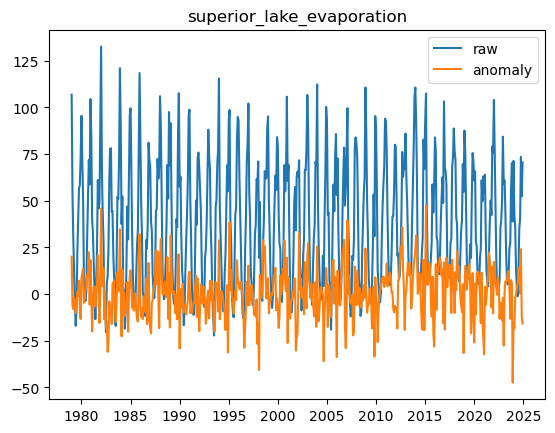

In [8]:
import matplotlib.pyplot as plt

var = "superior_lake_evaporation"

plt.figure()
plt.plot(X[var], label="raw")
plt.plot(X_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

Now that we have the anomalies in `X_anom`, we resume the existing feature construction workflow

In [9]:
# Shift the features to create lead times from 0 to 9 months
X_shifted = CFSTransformer(X_anom).shift_variables(lag=0, lead=10)

#Add a month variable to the shifted DataFrame
X_shifted = pd.concat([X_shifted, pd.DataFrame({'month': X_shifted.index.month,}, index=X_shifted.index)], axis=1)
X_shifted = pd.get_dummies(X_shifted, columns=['month'], prefix='month')

feature_column_order = (
    [f'month_{i}' for i in range(1, 13)] +
    [
        f'{lake}_{surface_type}_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for surface_type in ['lake', 'land']
        for comp in ['precipitation', 'evaporation', 'air_temperature']
        for m in range(10) #from 0 to 9, representing the 10 months of lead time
    ]
)

# Reorder the columns to match the specified order
X_reorg = X_shifted.reindex(columns=feature_column_order)

# Load in GLSEA SST data and merge with features
dataloader = DataLoader()
df_sst_k = dataloader.glsea(input_dir + 'glsea/oisst_sst_1981-2024.csv', units='K')

X_merged = pd.merge(df_sst_k, X_reorg, left_index=True, right_index=True, how='inner')

## Target Construction Workflow

This script prepares the target dataset for model training, including precipitation, evaporation, runoff, and net basin supply (NBS) for each Great Lake. The workflow is as follows:

### 1. Load L2SWBM Data
- Source: [L2SWBM dataset](https://zenodo.org/records/13883098)  
- Required file format for each lake (erie, miHuron, ontario, superior):  
  - Evaporation: `{lake}Evap_MonthlyRun.csv`  
  - Precipitation: `{lake}Precip_MonthlyRun.csv`  
  - Runoff: `{lake}Runoff_MonthlyRun.csv`  
- Each loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `{lake}_{component}_obs` (e.g., `erie_precipitation_obs`) for each lake and component.

### 2. Load GLCC Data
- Source: Great Lakes Coordinating Committee (GLCC)  
- Required file format for each lake (Erie, MichiganHuron, Ontario, Superior):  
  - `Lake{lake}_MonthlyNetBasinSupply_1900to2025.csv`  
- Loader function formats the data into a pandas DataFrame with a **datetime index**.  
- Columns are named `lake_nbs_obs` for each lake.

### 3. Assemble Target Matrix (`targets`)
- Combine L2SWBM components (precipitation, evaporation, runoff) with GLCC NBS for each lake into a single DataFrame.  
- Column naming convention: `{lake}_target_{component}` (e.g., `superior_target_evaporation`).  
- Only keep rows where **all target values are available** by dropping any rows with missing data.

### 4. Create Forecast-Like Lead Variables
- Apply `CFSProcessor.shift_variables` to generate **lead versions of all targets**, to minic the targeted **12-month forecast horizon** (lead times 0–11).

### 5. Reorder Target Columns
- Columns are organized to ensure a consistent structure for modeling:  

```text
superior_target_precipitation_mo0 … mo11
superior_target_evaporation_mo0 … mo11
superior_target_runoff_mo0 … mo11
superior_target_nbs_mo0 … mo11
michigan-huron_target_precipitation_mo0 … mo11
michigan-huron_target_evaporation_mo0 … mo11
...
ontario_target_nbs_mo0 … mo11


In [10]:
# Load L2SWBM data
l2 = dataloader.l2swbm(input_dir + 'l2swbm/')

# Load GLCC data
glcc = dataloader.glcc(input_dir + 'glcc/', units='mm')

# Targets are the components (P, E, R) fro L2SWBM and NBS from GLCC
targets = pd.DataFrame({
    'superior_target_evaporation': l2['superior_evaporation_obs'],
    'superior_target_precipitation': l2['superior_precipitation_obs'],
    'superior_target_runoff': l2['superior_runoff_obs'],
    'superior_target_nbs': glcc['superior_nbs_obs'],
    'michigan-huron_target_evaporation': l2['michigan-huron_evaporation_obs'],
    'michigan-huron_target_precipitation': l2['michigan-huron_precipitation_obs'],
    'michigan-huron_target_runoff': l2['michigan-huron_runoff_obs'],
    'michigan-huron_target_nbs': glcc['michigan-huron_nbs_obs'],
    'erie_target_evaporation': l2['erie_evaporation_obs'],
    'erie_target_precipitation': l2['erie_precipitation_obs'],
    'erie_target_runoff': l2['erie_runoff_obs'],
    'erie_target_nbs': glcc['erie_nbs_obs'],
    'ontario_target_evaporation': l2['ontario_evaporation_obs'],
    'ontario_target_precipitation': l2['ontario_precipitation_obs'],
    'ontario_target_runoff': l2['ontario_runoff_obs'],
    'ontario_target_nbs': glcc['ontario_nbs_obs']
})

# The dataframes are merged by date so we need to drop rows with NaN values
# This ensures that we only keep rows where all target values are available
targets = targets.dropna()

targets_shifted = CFSTransformer(targets).shift_variables(lag=0, lead=12)

### Convert targets to anomalies from the seasonal cycle as well

In [ ]:
# 1) Fit monthly climatology on TRAIN ONLY (avoid leakage)
scp_y = SeasonalCycleProcessor().fit(
    targets,
    var_list=list(targets.columns),          # explicit is good here
    baseline_time=train_slice,
    baseline_definition={
        "train_start": train_start_date,
        "train_end": train_end_date,
        "note": "targets climatology fit on training period only"
    },
)

# Save artifact so forecast notebook can load the same baseline
paths = scp_y.save("/Users/ljob/Desktop/cnbs-predictor/data/input/climatology/targets")

# 2) Transform full targets to anomalies
targets_anom = scp_y.transform(targets)

       superior_target_evaporation  superior_target_precipitation  \
month                                                               
1                       104.152684                      51.222286   
2                        59.538083                      33.388000   
3                        43.540848                      41.951143   
4                        17.028731                      54.532571   
5                         2.618745                      69.639143   
6                        -2.790549                      79.440000   
7                        -0.128799                      77.216571   
8                        16.491907                      73.048571   
9                        52.672722                      81.169429   
10                       74.393541                      75.807143   
11                      100.087221                      60.476571   
12                      118.229992                      53.731714   

       superior_target_runoff  su

Now we visualize the seasonal cycle and anomalies

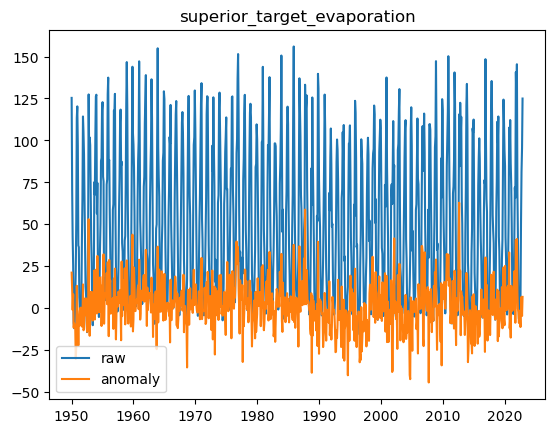

In [12]:
import matplotlib.pyplot as plt

var = "superior_target_evaporation"
plt.figure()
plt.plot(targets[var], label="raw")
plt.plot(targets_anom[var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

From here, we shift the targets to create lead variables, using targets_anom instead of targets

In [13]:
# Shift the targets to create lead variables
targets_lead = CFSTransformer(targets_anom).shift_variables(lag=0, lead=12)

# Define the target column order for the 12-month forecast
target_column_order =[
        f'{lake}_target_{comp}_mo{m}'
        for lake in ['superior', 'michigan-huron', 'erie', 'ontario']
        for comp in ['precipitation', 'evaporation', 'runoff', 'nbs']
        for m in range(12) #from 0 to 11, representing the 12 month forecast
        ]

# Reorganize the targets DataFrame to match the target column order
targets_reorg = targets_lead.reindex(columns=target_column_order)

## Align Features and Targets

This step ensures that the **features** and **target** datasets are aligned:  

### 1. Subset the reorganized target DataFrame (`targets_reorg`) to only include rows corresponding to the **dates present in the merged feature dataset** (`X_merged`).  
   - This guarantees that each row of features has a matching target for model training.  
   - The aligned target dataset is stored in `aligned_y`.

### 2. Print summary information for verification:  
   - **Number of features** (`X_merged.shape[1]`)  
   - **Number of target variables** (`aligned_y.shape[1]`)  

This alignment is crucial for ensuring consistent input-output pairing before training or forecasting.


In [14]:
# Make sure the features and target indices/dates align
aligned_X, aligned_y = X_merged.align(targets_reorg, join='inner', axis=0)
print(f'Number of Features: {aligned_X.shape[1]}')
print(f'Number of Targets: {aligned_y.shape[1]}')

Number of Features: 256
Number of Targets: 192


## Train-Test Split by Date

This step divides the dataset into **training** and **testing** subsets based on date ranges, rather than random sampling, to **preserve seasonal and temporal structure**:  

### 1. **Training Set (≈80% of data)**  
   - Start: January 1982  
   - End: December 2005  
   - `X_train` and `y_train` contain features and targets within this range.  

### 2. **Testing/Validation Set (≈20% of data)**  
   - Start: January 2006  
   - End: January 2011  
   - `X_test` and `y_test` contain features and targets within this range.  

This chronological split ensures that the model is evaluated on **future data**, maintaining realistic forecasting conditions and seasonal patterns.


In [15]:
X_train = aligned_X[train_start_date:train_end_date]
y_train = aligned_y[train_start_date:train_end_date]
X_test = aligned_X[val_start_date:val_end_date]
y_test = aligned_y[val_start_date:val_end_date]

## Feature and Target Standardization

This step standardizes the features and targets to improve model training and convergence:  

### 1. **Define Scalers**  
   - `x_scaler` and `y_scaler` are instances of `StandardScaler` from `scikit-learn`.  

### 2. **Fit and Transform Training Data**  
   - The scalers are **fit only on the training data** to avoid data leakage.  
   - `X_train_scaled` and `y_train_scaled` contain standardized training features and targets.  

### 3. **Transform Testing Data**  
   - Apply the same fitted scalers to the testing data (`X_test_scaled` and `y_test_scaled`) to ensure consistent scaling.  

### 4. **Save Scalers for Future Use**  
   - The fitted scalers are saved using `joblib.dump` so they can be applied during the **prediction phase** on new data, maintaining the same scaling.


In [16]:
# Define the scaler we want to use
x_scaler = StandardScaler()
y_scaler = StandardScaler()

# Standardize the data
# This will scale the features and targets between 0 and 1
# It is important to fit the scaler on the training data and then transform both train and test data
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# Save the scalers to use later during the prediction phase
joblib.dump(x_scaler, input_dir + 'input/scalers/x_scaler_anom.joblib')
joblib.dump(y_scaler, input_dir + 'input/scalers/y_scaler_anom.joblib')

['/Users/ljob/Desktop/cnbs-predictor/data/input/scalers/y_scaler_anom.joblib']

## Gaussian Process Regression (GPR) Model Setup, Training and Evaluation

This step defines, trains, and evaluates a **Gaussian Process Regression (GPR)** model using the preprocessed features and targets.  

### 1. Kernel Selection
- Several kernel options are explored for modeling:  
  - **Basic kernel:** `ConstantKernel * RBF`  
  - **Matt's optimal kernel:** `1.0 * Matern(nu=1.5) * RationalQuadratic()` (currently used)  
  - Optional seasonal components: `ExpSineSquared` for modeling periodicity, or combinations of `RBF`, `Matern`, and `RationalQuadratic`.  

### 2. Model Definition
- Initialize the GPR model with the selected kernel.  
- Parameters:  
  - `alpha=0.1` → observation noise level  
  - `n_restarts_optimizer=10` → number of restarts for kernel hyperparameter optimization  
  - `random_state=42` → ensures reproducibility  

### 3. Model Training
- Fit the GPR model on the **scaled training data** (`X_train_scaled` and `y_train_scaled`).  
- Save the trained model using `joblib` for future use.

### 4. Predictions and Evaluation
- Predict on the **scaled testing features** (`X_test_scaled`) and obtain uncertainty estimates (`sigma`).  
- Compute **R² score** on the testing data to evaluate model performance:  
  ```python
  r2 = r2_score(y_test_scaled, y_pred_GP)

(The function below should be added to the data processor)

In [17]:
_MO_RE = re.compile(r"_mo(\d+)$")

def add_climatology_back_leadwide(
    df_anom_leadwide: pd.DataFrame,
    scp_y: "SeasonalCycleProcessor",
    strict: bool = False,
) -> pd.DataFrame:
    """
    Convert lead-wide anomaly targets to lead-wide absolute targets by adding a monthly climatology.

    This is designed for targets that have already been shifted into lead form, where each column
    ends with `_mo{k}` and the DataFrame index represents the *initialization* date.

    Month alignment rule
    --------------------
    For a given init date `t` and lead `k` months, the verifying month is:
        verifying_month = month(t + k months)

    Parameters
    ----------
    df_anom_leadwide : pd.DataFrame
        Anomaly DataFrame indexed by init date (must be a DatetimeIndex).
        Columns must end with `_mo{k}` where k is lead in months, e.g.:
            'superior_target_precipitation_mo0', ..., '..._mo11'

        Values must be in anomaly units (i.e., NOT standardized).

    scp_y : SeasonalCycleProcessor
        A fitted seasonal-cycle processor with attribute `climatology`:
            - index: months 1..12 (int)
            - columns: base (unshifted) variable names, e.g. 'superior_target_precipitation'
            - values: monthly climatological means in absolute units

    strict : bool, default False
        If True, raise an error if any column does not match the `_mo{k}` pattern.

    Returns
    -------
    pd.DataFrame
        Same shape/columns/index as `df_anom_leadwide`, but in absolute units
        (monthly climatology added back to each lead column).
    """
    if not isinstance(df_anom_leadwide.index, pd.DatetimeIndex):
        raise ValueError("df_anom_leadwide must have a DatetimeIndex (init dates).")

    if not hasattr(scp_y, "climatology"):
        raise AttributeError("scp_y must have a `climatology` attribute (fit the processor first).")

    clim = scp_y.climatology

    if not isinstance(clim, pd.DataFrame):
        raise TypeError("scp_y.climatology must be a pandas DataFrame (month x base_var).")

    # Optional sanity check: months should be 1..12
    # (Don't force order; just ensure membership.)
    expected_months = set(range(1, 13))
    clim_months = set(pd.Index(clim.index).astype(int).tolist())
    if not expected_months.issubset(clim_months):
        raise ValueError(
            "scp_y.climatology index must include months 1..12. "
            f"Got: {sorted(clim_months)[:15]}..."
        )

    out = df_anom_leadwide.copy()
    idx = out.index

    for col in out.columns:
        m = _MO_RE.search(col)
        if m is None:
            if strict:
                raise ValueError(f"Column '{col}' does not end with _mo{{k}}.")
            continue

        lead = int(m.group(1))
        base = _MO_RE.sub("", col)  # strip _mo{k}

        if base not in clim.columns:
            raise KeyError(
                f"Base variable '{base}' not found in climatology columns. "
                "This usually means climatology was fit on different variable names."
            )

        verifying_month = (idx + pd.DateOffset(months=lead)).month  # 1..12
        out[col] = out[col].to_numpy() + clim.loc[verifying_month, base].to_numpy()

    return out

In [18]:
# Testing Different Kernels
# Basic kernel using ConstantKernel:
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))

# Matt's optimal kernel: 
kernel = 1.0 * Matern(nu=1.5) * RationalQuadratic()

#kernel = 1.0 * Matern(length_scale=50.0, nu=1.5, length_scale_bounds=(1e-10, 1e3)) \
#         * RationalQuadratic(alpha=0.0001, length_scale=.01, length_scale_bounds=(1e-10, 1e3))

# Test to add a seasonality component:
#period = 3.0  # Period of the season
#kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + ExpSineSquared(length_scale=1.0, periodicity=period, periodicity_bounds=(1e-2, 1e2))

# Set up the model
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.1, n_restarts_optimizer=10, random_state=42)

# Fit the model
gpr.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(gpr, input_dir + 'input/models/GP_trained_model_anom.joblib')

# Predictions
y_pred_GP, sigma = gpr.predict(X_test_scaled, return_std=True)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_GP)

print(f"R² Score: {r2:.4f}")
# Optimized kernel after training
print("Optimized Kernel:", gpr.kernel_)

# Kernel hyperparameters
print("Kernel Hyperparameters:", gpr.kernel_.theta)

R² Score: 0.3478
Optimized Kernel: 2.47**2 * Matern(length_scale=68.8, nu=1.5) * RationalQuadratic(alpha=0.0012, length_scale=1e-05)
Kernel Hyperparameters: [  1.80521624   4.23142125  -6.7239853  -11.51292546]


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [19]:
def unscale_to_df(y_std, scaler, index, columns):
    return pd.DataFrame(scaler.inverse_transform(y_std), index=index, columns=columns)

def r2_flat(a, b):
    return r2_score(a.to_numpy().ravel(), b.to_numpy().ravel())

# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_GP,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.3202772255517534
R² (absolute, reconstructed): 0.7527982553734005
R² (absolute, climatology-only): 0.635021070928666


In [20]:
import xgboost as xgb

# Create the XGBoost regressor 
xgb = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'  # for regression
)

# Train the model
xgb.fit(X_train_scaled, y_train_scaled)

# Predict on the test set
y_pred_XGB = xgb.predict(X_test_scaled)

# Save the trained model
joblib.dump(xgb, input_dir + 'input/models/XGB_trained_model_anom.joblib')

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_XGB)

print(f"R² Score: {r2:.4f}")

R² Score: 0.2692


In [21]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_XGB,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.28432108904040465
R² (absolute, reconstructed): 0.7397217188650385
R² (absolute, climatology-only): 0.635021070928666


In [22]:
## Random Forest Regressor Model:

# Initialize RandomForestRegressor
rfr_model = skRFR(random_state=42)

# Train the model
trained_RFR = rfr_model.fit(X_train_scaled, y_train_scaled)

# Save the trained model
joblib.dump(trained_RFR, input_dir + 'input/models/RF_trained_model_anom.joblib')

# Predict on the test set
y_pred_RFR = trained_RFR.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_RFR)

print(f"R² Score: {r2:.4f}")

R² Score: 0.0661


In [23]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_RFR,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): 0.11043096207723857
R² (absolute, reconstructed): 0.6764813150202083
R² (absolute, climatology-only): 0.635021070928666


(388, 256) (388, 192)
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0728 - mae: 0.7936 - val_loss: 1.1552 - val_mae: 0.8003
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9637 - mae: 0.7464 - val_loss: 1.1250 - val_mae: 0.7867
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9343 - mae: 0.7336 - val_loss: 1.1127 - val_mae: 0.7816
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9099 - mae: 0.7241 - val_loss: 1.1051 - val_mae: 0.7795
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8810 - mae: 0.7128 - val_loss: 1.1000 - val_mae: 0.7787
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8482 - mae: 0.6990 - val_loss: 1.0977 - val_mae: 0.7790
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8148 - mae: 0.6860 - val_loss: 1.0885 - val_mae: 0.7775
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7814 - mae: 0.6725 - val_loss: 1.0753 - val_mae: 0.7737
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

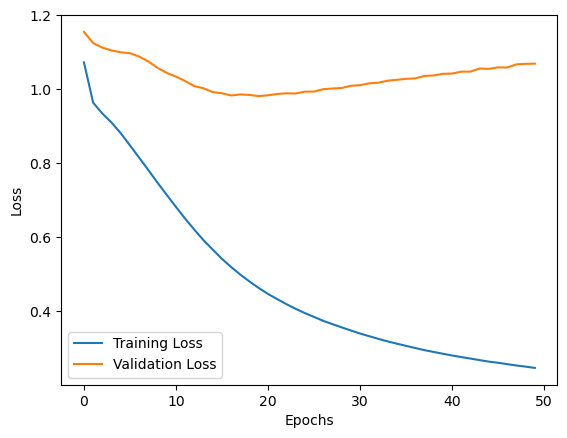

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
R² Score: -0.0867


In [24]:
## Neural Network ##

# Define the neural network architecture
nn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train.shape[1])
])

# Compile the model
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae']) # Using mean squared error (mse) as the loss function

print(X_train_scaled.shape, y_train_scaled.shape)
# Fit the model to the training data
history = nn_model.fit(X_train_scaled, y_train_scaled, epochs=50, batch_size=32, validation_split=0.2, verbose=1)#, callbacks=[early_stopping])

# Plotting the training and validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
joblib.dump(nn_model, input_dir + 'input/models/NN_trained_model_anom.joblib')

# Predict on the test set
y_pred_NN = nn_model.predict(X_test_scaled)

# Evaluate the model
r2 = r2_score(y_test_scaled, y_pred_NN)

print(f"R² Score: {r2:.4f}")

In [25]:
y_gp_anom = unscale_to_df(y_pred_GP, y_scaler, y_test.index, y_test.columns)
y_gp_abs = add_climatology_back_leadwide(y_gp_anom, scp_y)
y_gp_abs['model'] = 'GP'

y_rf_anom = unscale_to_df(y_pred_RFR, y_scaler, y_test.index, y_test.columns)
y_rf_abs = add_climatology_back_leadwide(y_rf_anom, scp_y)
y_rf_abs['model'] = 'RFR'

y_nn_anom = unscale_to_df(y_pred_NN, y_scaler, y_test.index, y_test.columns)
y_nn_abs = add_climatology_back_leadwide(y_nn_anom, scp_y)
y_nn_abs['model'] = 'NN'

y_xgb_anom = unscale_to_df(y_pred_XGB, y_scaler, y_test.index, y_test.columns)
y_xgb_abs = add_climatology_back_leadwide(y_xgb_anom, scp_y)
y_xgb_abs['model'] = 'XGB'

df_all = pd.concat([y_gp_abs, y_rf_abs, y_nn_abs, y_xgb_abs], axis=0)

df_all = df_all.reset_index()
df_all = df_all.rename(columns={'date': 'cfs_run'})
print(df_all)

/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_74025/2790089697.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  y_gp_abs['model'] = 'GP'
/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_74025/2790089697.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  y_rf_abs['model'] = 'RFR'
/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_74025/2790089697.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

       cfs_run  superior_target_precipitation_mo0  \
0   2014-01-01                          63.206483   
1   2014-02-01                          46.685762   
2   2014-03-01                          42.576095   
3   2014-04-01                          87.278190   
4   2014-05-01                          76.631672   
..         ...                                ...   
383 2021-09-01                          75.638020   
384 2021-10-01                          64.054490   
385 2021-11-01                          59.504113   
386 2021-12-01                          59.743505   
387 2022-01-01                          45.218905   

     superior_target_precipitation_mo1  superior_target_precipitation_mo2  \
0                            45.093355                          41.650209   
1                            43.008849                          84.039235   
2                            84.259145                          74.803545   
3                            74.083495                 

/var/folders/2w/ddc7n0594ydfswtzw_mmfs6c0000gp/T/ipykernel_74025/2790089697.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  y_xgb_abs['model'] = 'XGB'


In [26]:
# Step 1: Melt into long format
df_melted = df_all.melt(
    id_vars=['cfs_run', 'model'],
    var_name='variable',
    value_name='value'
)
print(df_melted)


         cfs_run model                           variable       value
0     2014-01-01    GP  superior_target_precipitation_mo0   63.206483
1     2014-02-01    GP  superior_target_precipitation_mo0   46.685762
2     2014-03-01    GP  superior_target_precipitation_mo0   42.576095
3     2014-04-01    GP  superior_target_precipitation_mo0   87.278190
4     2014-05-01    GP  superior_target_precipitation_mo0   76.631672
...          ...   ...                                ...         ...
74491 2021-09-01   XGB            ontario_target_nbs_mo11   12.324829
74492 2021-10-01   XGB            ontario_target_nbs_mo11   68.750977
74493 2021-11-01   XGB            ontario_target_nbs_mo11   68.313264
74494 2021-12-01   XGB            ontario_target_nbs_mo11  188.388967
74495 2022-01-01   XGB            ontario_target_nbs_mo11  182.879645

[74496 rows x 4 columns]


In [27]:

# Step 2: Split into lake, variable, and month_offset
split_cols = df_melted['variable'].str.rsplit('_', n=2, expand=True)
df_melted['lake'] = split_cols[0].str.replace('_target', '', regex=False)
df_melted['variable'] = split_cols[1]
df_melted['month_offset'] = split_cols[2].str.replace('mo', '', regex=False).astype(int)

# Step 3: Compute forecast_month (vectorized, better)
df_melted['cfs_run'] = pd.to_datetime(df_melted['cfs_run'])
df_melted['forecast_month'] = (
    df_melted['cfs_run'].dt.to_period('M') +
    df_melted['month_offset']
).astype(str)
print(df_melted)


         cfs_run model       variable       value      lake  month_offset  \
0     2014-01-01    GP  precipitation   63.206483  superior             0   
1     2014-02-01    GP  precipitation   46.685762  superior             0   
2     2014-03-01    GP  precipitation   42.576095  superior             0   
3     2014-04-01    GP  precipitation   87.278190  superior             0   
4     2014-05-01    GP  precipitation   76.631672  superior             0   
...          ...   ...            ...         ...       ...           ...   
74491 2021-09-01   XGB            nbs   12.324829   ontario            11   
74492 2021-10-01   XGB            nbs   68.750977   ontario            11   
74493 2021-11-01   XGB            nbs   68.313264   ontario            11   
74494 2021-12-01   XGB            nbs  188.388967   ontario            11   
74495 2022-01-01   XGB            nbs  182.879645   ontario            11   

      forecast_month  
0            2014-01  
1            2014-02  
2     

In [28]:
df_melted_tmp = df_melted.drop(columns=['month_offset'])

# Step 4: Pivot with BOTH lake + variable as columns
df_tidy = df_melted.pivot_table(
    index=['cfs_run', 'model', 'forecast_month'],
    columns=['lake', 'variable'],
    values='value'
)

# Flatten MultiIndex columns → "lake_variable"
df_tidy.columns = [f"{lake}_{var}" for lake, var in df_tidy.columns]

df_tidy = df_tidy.reset_index()

# Step 5: Reorder columns
expected_vars = ["precipitation", "evaporation", "runoff", "nbs"]
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']

ordered_feature_cols = [
    f"{lake}_{var}"
    for lake in lakes
    for var in expected_vars
    if f"{lake}_{var}" in df_tidy.columns
]

cols = ["cfs_run", "forecast_month", "model"] + ordered_feature_cols

df_final = df_tidy[cols]

# Convert cfs_run back to YYYYMMDDHH format
df_final["cfs_run"] = pd.to_datetime(df_final["cfs_run"]).dt.strftime("%Y%m%d%H")

In [29]:
df_final.to_csv(input_dir + 'output/CNBS_test_anom.csv', index=True)

In [30]:
# 1) standardized -> anomaly units (lead-wide columns already present)
y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_test.index, y_test.columns)
y_pred_anom = unscale_to_df(y_pred_NN,    y_scaler, y_test.index, y_test.columns)

print("R² (anomaly, lead-wide):", r2_flat(y_true_anom, y_pred_anom))

# 2) anomaly -> absolute (lead-aware)
y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

print("R² (absolute, reconstructed):", r2_flat(y_true_abs, y_pred_abs))

# 3) climatology-only baseline in absolute space (lead-aware!)
y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)
print("R² (absolute, climatology-only):", r2_flat(y_true_abs, y_clim_abs))

R² (anomaly, lead-wide): -0.04810547530237397
R² (absolute, reconstructed): 0.6188247447531048
R² (absolute, climatology-only): 0.635021070928666


Calculate Skill Metrics on the Test Data Set

In [31]:
def compute_skill_metrics(
    model,
    y_true_std,
    y_pred_std,
    y_scaler,
    *,
    y_index,
    y_columns,
    seasonal_processor=None,
    by_lead=False,
):
    """
    Compute skill metrics for lead-wide targets in:
      (1) anomaly space
      (2) absolute reconstructed space (adds monthly climatology back; lead-aware)
      (3) absolute climatology-only baseline (lead-aware)

    Parameters
    ----------
    model : str
        Model name.

    y_true_std : np.ndarray
        True values in standardized space, shape (n_samples, n_targets).

    y_pred_std : np.ndarray
        Predicted values in standardized space, shape (n_samples, n_targets).

    y_scaler : sklearn-like scaler
        Must implement inverse_transform() mapping standardized -> anomaly units.

    y_index : pd.DatetimeIndex
        Index for the target rows (init dates).

    y_columns : list[str]
        Target column names, expected to include suffixes like '_mo0'..'_mo11'.

    seasonal_processor : SeasonalCycleProcessor, optional
        If provided, must contain `climatology` used to reconstruct absolute values.

    by_lead : bool
        If True, adds R² by lead month as columns: R²_mo0 ... R²_mo11
        (computed in each space where applicable).

    Returns
    -------
    pd.DataFrame
        One or more rows (one per Space) with metrics.
        Columns include: Model, Space, RMSE, R², Bias, Std Dev, CRPS (+ optional lead columns)
    """

    def to_df(y_std):
        return pd.DataFrame(
            y_scaler.inverse_transform(y_std),
            index=y_index,
            columns=y_columns
        )

    def flat_metrics(y_true_df, y_pred_df):
        yt = y_true_df.to_numpy().ravel()
        yp = y_pred_df.to_numpy().ravel()

        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)  # IMPORTANT: consistent space (not standardized)
        bias = np.mean(yp - yt)
        std_dev = np.std(yp - yt, ddof=1)
        crps = np.mean(crps_ensemble(yt, yp[:, None]))  # deterministic CRPS
        return rmse, r2, bias, std_dev, crps

    def r2_by_lead(y_true_df, y_pred_df):
        out = {}
        for lead in range(12):
            cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
            if not cols:
                continue
            out[f"R²_mo{lead}"] = r2_score(
                y_true_df[cols].to_numpy().ravel(),
                y_pred_df[cols].to_numpy().ravel()
            )
        return out

    rows = []

    # --- (1) anomaly space ---
    y_true_anom = to_df(y_true_std)
    y_pred_anom = to_df(y_pred_std)

    rmse, r2, bias, std_dev, crps = flat_metrics(y_true_anom, y_pred_anom)
    row = {
        "Model": model,
        "Space": "anomaly",
        "RMSE": round(rmse, 3),
        "R²": round(r2, 3),
        "Bias": round(bias, 3),
        "Std Dev": round(std_dev, 3),
        "CRPS": round(crps, 3),
    }
    if by_lead:
        row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_anom, y_pred_anom).items()})
    rows.append(row)

    # --- (2) absolute reconstructed + (3) climatology-only ---
    if seasonal_processor is not None:
        y_true_abs = add_climatology_back_leadwide(y_true_anom, seasonal_processor)
        y_pred_abs = add_climatology_back_leadwide(y_pred_anom, seasonal_processor)

        rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_pred_abs)
        row = {
            "Model": model,
            "Space": "absolute_reconstructed",
            "RMSE": round(rmse, 3),
            "R²": round(r2, 3),
            "Bias": round(bias, 3),
            "Std Dev": round(std_dev, 3),
            "CRPS": round(crps, 3),
        }
        if by_lead:
            row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_pred_abs).items()})
        rows.append(row)

        # climatology-only baseline: 0 anomalies + climatology
        y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, seasonal_processor)

        rmse, r2, bias, std_dev, crps = flat_metrics(y_true_abs, y_clim_abs)
        row = {
            "Model": model,
            "Space": "absolute_climatology_only",
            "RMSE": round(rmse, 3),
            "R²": round(r2, 3),
            "Bias": round(bias, 3),
            "Std Dev": round(std_dev, 3),
            "CRPS": round(crps, 3),
        }
        if by_lead:
            row.update({k: round(v, 3) for k, v in r2_by_lead(y_true_abs, y_clim_abs).items()})
        rows.append(row)

    return pd.DataFrame(rows)

In [32]:
skill_GP = compute_skill_metrics(
    "Gaussian Process",
    y_test_scaled,
    y_pred_GP,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_RF = compute_skill_metrics(
    "Random Forest",
    y_test_scaled,
    y_pred_RFR,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_XGB = compute_skill_metrics(
    "XG Boost",
    y_test_scaled,
    y_pred_XGB,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

skill_NN = compute_skill_metrics(
    "Neural Network",
    y_test_scaled,
    y_pred_NN,
    y_scaler,
    y_index=y_test.index,
    y_columns=y_test.columns,
    seasonal_processor=scp_y,   # important
    by_lead=True,              # flip to True when you want all the lead times
)

results_df = pd.concat([skill_GP, skill_RF, skill_NN, skill_XGB], ignore_index=True)

In [33]:
results_df

,Model,Space,RMSE,R²,Bias,Std Dev,CRPS,R²_mo0,R²_mo1,R²_mo2,R²_mo3,R²_mo4,R²_mo5,R²_mo6,R²_mo7,R²_mo8,R²_mo9,R²_mo10,R²_mo11
0,Gaussian Process,anomaly,38.709,0.320,-0.782,38.703,22.664,0.372,0.414,0.428,0.436,0.424,0.413,0.428,0.400,0.378,0.365,-0.093,-0.141
1,Gaussian Process,absolute_reconstructed,38.709,0.753,-0.782,38.703,22.664,0.773,0.788,0.795,0.801,0.791,0.784,0.789,0.779,0.772,0.768,0.599,0.585
2,Gaussian Process,absolute_climatology_only,47.035,0.635,-2.806,46.953,28.446,0.636,0.636,0.640,0.644,0.636,0.631,0.630,0.630,0.632,0.634,0.633,0.636
3,Random Forest,anomaly,44.283,0.110,-2.238,44.228,26.866,0.106,0.124,0.129,0.133,0.150,0.134,0.134,0.143,0.159,0.126,-0.003,-0.012
4,Random Forest,absolute_reconstructed,44.283,0.676,-2.238,44.228,26.866,0.676,0.683,0.688,0.693,0.692,0.682,0.680,0.684,0.692,0.681,0.632,0.632
5,Random Forest,absolute_climatology_only,47.035,0.635,-2.806,46.953,28.446,0.636,0.636,0.640,0.644,0.636,0.631,0.630,0.630,0.632,0.634,0.633,0.636
6,Neural Network,anomaly,48.068,-0.048,-3.070,47.971,29.195,0.071,0.031,0.143,0.097,0.128,0.000,0.098,0.075,0.111,-0.014,-0.574,-0.769
7,Neural Network,absolute_reconstructed,48.068,0.619,-3.070,47.971,29.195,0.663,0.649,0.693,0.681,0.684,0.633,0.667,0.659,0.674,0.630,0.423,0.357
8,Neural Network,absolute_climatology_only,47.035,0.635,-2.806,46.953,28.446,0.636,0.636,0.640,0.644,0.636,0.631,0.630,0.630,0.632,0.634,0.633,0.636
9,XG Boost,anomaly,39.720,0.284,-2.842,39.619,23.502,0.358,0.358,0.365,0.368,0.379,0.404,0.387,0.374,0.381,0.344,-0.142,-0.179


In [34]:
# start from results_df (the big table)
base = results_df[["Model", "Space", "RMSE", "R²", "Bias", "Std Dev", "CRPS"]].copy()

recon = base[base["Space"] == "absolute_reconstructed"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_abs", "RMSE": "RMSE_abs"}
)
anom = base[base["Space"] == "anomaly"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_anom", "RMSE": "RMSE_anom"}
)
clim = base[base["Space"] == "absolute_climatology_only"][["Model", "R²", "RMSE"]].rename(
    columns={"R²": "R²_clim", "RMSE": "RMSE_clim"}
)

summary = (
    recon.merge(anom, on="Model")
         .merge(clim, on="Model")
         .assign(delta_R2=lambda d: d["R²_abs"] - d["R²_clim"])
         .sort_values("delta_R2", ascending=False)
         .reset_index(drop=True)
)

summary.style.format({
    "R²_abs": "{:.3f}", "R²_anom": "{:.3f}", "R²_clim": "{:.3f}", "delta_R2": "{:.3f}",
    "RMSE_abs": "{:.2f}", "RMSE_anom": "{:.2f}", "RMSE_clim": "{:.2f}",
})

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2
0,Gaussian Process,0.753,38.71,0.320,38.71,0.635,47.03,0.118
1,XG Boost,0.740,39.72,0.284,39.72,0.635,47.03,0.105
2,Random Forest,0.676,44.28,0.110,44.28,0.635,47.03,0.041
3,Neural Network,0.619,48.07,-0.048,48.07,0.635,47.03,-0.016


In [35]:
def plot_styled_table(df):
    fig, ax = plt.subplots(figsize=(1.8 * len(df.columns), 1 + 0.5 * len(df)))
    ax.axis('off')

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='center',
        cellLoc='center',
        edges='closed'
    )

    ncols = len(df.columns)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(11)

        cell.set_height(0.12)

        # Wider model column
        if col == 0:
            cell.set_width(0.25)
        else:
            cell.set_width(0.75 / (ncols - 1))

    table.auto_set_font_size(False)

    plt.tight_layout()
    plt.show()

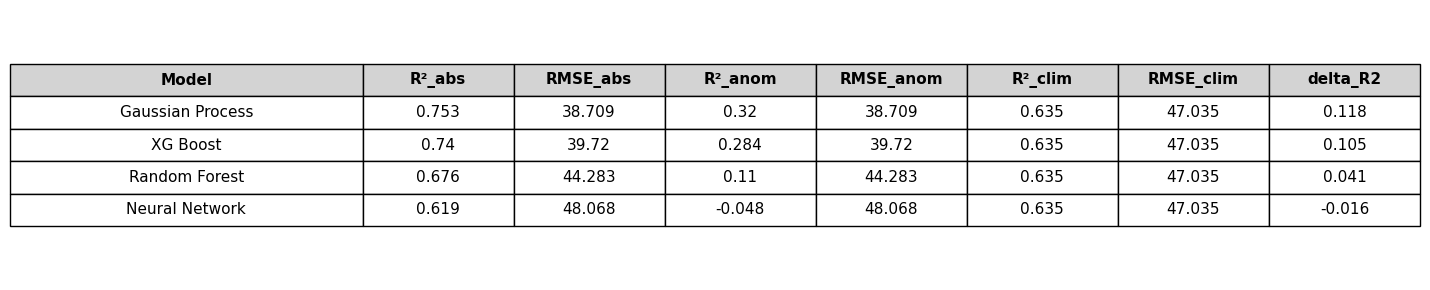

In [36]:
plot_styled_table(summary)

In [37]:
lead_cols = [c for c in results_df.columns if c.startswith("R²_mo")]

lead_skill = (
    results_df[results_df["Space"] == "anomaly"][["Model"] + lead_cols]
    .melt(id_vars="Model", var_name="lead", value_name="R²")
)

lead_skill["lead"] = lead_skill["lead"].str.replace("R²_mo", "").astype(int)
lead_skill = lead_skill.sort_values(["Model", "lead"])

#### Plot anomaly skill by lead month and method

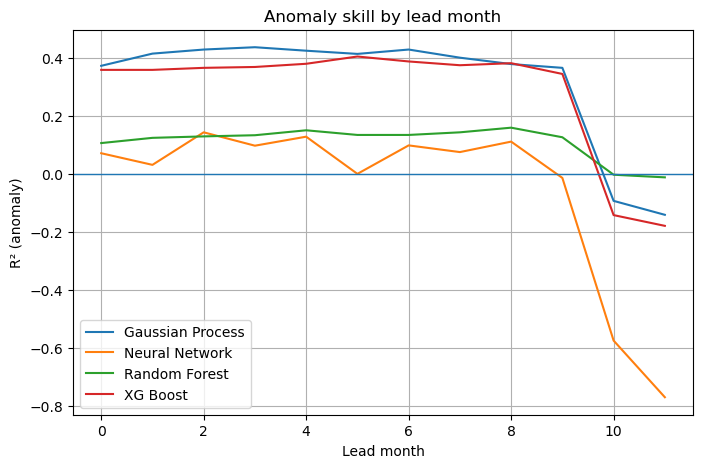

In [38]:
plt.figure(figsize=(8,5))
for model, g in lead_skill.groupby("Model"):
    plt.plot(g["lead"], g["R²"], label=model)

plt.axhline(0, linewidth=1)
plt.xlabel("Lead month")
plt.ylabel("R² (anomaly)")
plt.title("Anomaly skill by lead month")
plt.legend()
plt.grid(True)
plt.show()

### Plot skill score relative to climatology 

Current setup below will just run this analysis for the last model to be tested, so the results don't reflect the "best" modeling efforts necessarily

In [39]:
summary = summary.assign(
    SkillScore=lambda d: 1 - d["RMSE_abs"] / d["RMSE_clim"]
)

summary.style.format({
    "R²_abs": "{:.3f}",
    "R²_clim": "{:.3f}",
    "delta_R2": "{:.3f}",
    "RMSE_abs": "{:.2f}",
    "RMSE_clim": "{:.2f}",
    "SkillScore": "{:.3f}"
})

,Model,R²_abs,RMSE_abs,R²_anom,RMSE_anom,R²_clim,RMSE_clim,delta_R2,SkillScore
0,Gaussian Process,0.753,38.71,0.320000,38.709000,0.635,47.03,0.118,0.177
1,XG Boost,0.740,39.72,0.284000,39.720000,0.635,47.03,0.105,0.156
2,Random Forest,0.676,44.28,0.110000,44.283000,0.635,47.03,0.041,0.059
3,Neural Network,0.619,48.07,-0.048000,48.068000,0.635,47.03,-0.016,-0.022


In [40]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def rmse_by_lead(y_true_df, y_pred_df):
    results = {}
    for lead in range(12):
        cols = [c for c in y_true_df.columns if c.endswith(f"_mo{lead}")]
        if not cols:
            continue
        
        yt = y_true_df[cols].to_numpy().ravel()
        yp = y_pred_df[cols].to_numpy().ravel()
        
        results[lead] = rmse(yt, yp)
        
    return results

In [41]:
rmse_model = rmse_by_lead(y_true_abs, y_pred_abs)
rmse_clim  = rmse_by_lead(y_true_abs, y_clim_abs)

skill_by_lead = {
    lead: 1 - rmse_model[lead] / rmse_clim[lead]
    for lead in rmse_model
}

skill_by_lead_df = (
    pd.DataFrame({
        "lead": list(skill_by_lead.keys()),
        "SkillScore": list(skill_by_lead.values())
    })
    .sort_values("lead")
)

skill_by_lead_df

,lead,SkillScore
0,0,0.038236
1,1,0.018244
2,2,0.076766
3,3,0.052632
4,4,0.068626
5,5,0.002059
6,6,0.051713
7,7,0.039724
8,8,0.058359
9,9,-0.006295


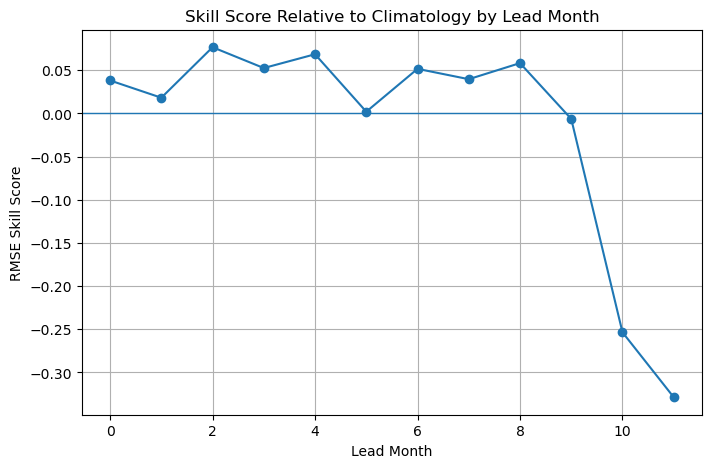

In [42]:
plt.figure(figsize=(8,5))
plt.plot(skill_by_lead_df["lead"], skill_by_lead_df["SkillScore"], marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Lead Month")
plt.ylabel("RMSE Skill Score")
plt.title("Skill Score Relative to Climatology by Lead Month")
plt.grid(True)
plt.show()

In [43]:
targets

,superior_target_evaporation,superior_target_precipitation,superior_target_runoff,superior_target_nbs,michigan-huron_target_evaporation,michigan-huron_target_precipitation,michigan-huron_target_runoff,michigan-huron_target_nbs,erie_target_evaporation,erie_target_precipitation,erie_target_runoff,erie_target_nbs,ontario_target_evaporation,ontario_target_precipitation,ontario_target_runoff,ontario_target_nbs
date,,,,,,,,,,,,,,,,
1950-01-01,125.357918,88.75,33.2,14.026862,95.709892,91.03,104.7,94.677343,38.810083,166.00,238.30,550.186890,75.883804,111.8,271.8,375.028505
1950-02-01,70.413371,36.98,25.5,-8.961299,59.667369,64.88,65.8,57.923217,40.703714,94.80,136.20,258.878682,77.272852,88.8,147.1,188.013699
1950-03-01,42.505142,62.08,31.0,49.607194,36.461632,77.05,81.9,124.142145,26.439582,97.00,162.60,427.763105,43.856645,71.4,196.6,323.419078
1950-04-01,25.310708,89.29,48.1,142.365472,23.005784,84.70,125.2,200.438931,16.345690,101.30,161.40,367.968263,17.753245,60.1,283.2,529.412835
1950-05-01,-8.965747,147.60,115.5,340.750102,0.003105,55.79,110.9,130.425081,10.834650,47.30,68.10,115.222385,2.194818,52.9,117.2,182.353310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-08-01,5.267900,73.93,36.0,83.476933,41.785871,84.30,33.5,38.130921,112.690526,101.69,20.42,24.484757,69.512130,84.0,40.7,22.364085
2022-09-01,50.655000,104.23,36.5,83.763871,76.020764,71.23,32.2,-21.176080,161.345409,88.97,25.36,-90.598246,88.009890,65.4,53.8,-39.955686
2022-10-01,81.158000,63.07,41.3,13.684743,87.836585,72.61,37.1,-2.383183,177.551294,50.74,17.61,-154.109940,84.626460,32.1,45.6,-46.448485


# Integrated NBS skill

Trying out 1, 3, and 6 month integrated NBS skill

In [44]:
def compute_integrated_skill(
    y_true_df,
    y_pred_df,
    variable="superior_target_nbs",
    window=3
):
    """
    Compute skill on integrated (rolling-sum) lead windows.

    Parameters
    ----------
    y_true_df : pd.DataFrame
        Reconstructed absolute true values (with _mo{k} columns)

    y_pred_df : pd.DataFrame
        Reconstructed absolute predicted values

    variable : str
        Base variable name (e.g., 'superior_target_nbs')

    window : int
        Integration window (1, 3, 6 months)

    Returns
    -------
    float
        R² for integrated values
    """

    lead_cols = [
        f"{variable}_mo{k}" for k in range(12)
        if f"{variable}_mo{k}" in y_true_df.columns
    ]

    y_true_vals = y_true_df[lead_cols].values
    y_pred_vals = y_pred_df[lead_cols].values

    # rolling integration across lead axis
    integrated_true = []
    integrated_pred = []

    for start in range(len(lead_cols) - window + 1):
        integrated_true.append(
            y_true_vals[:, start:start+window].sum(axis=1)
        )
        integrated_pred.append(
            y_pred_vals[:, start:start+window].sum(axis=1)
        )

    integrated_true = np.concatenate(integrated_true)
    integrated_pred = np.concatenate(integrated_pred)

    return r2_score(integrated_true, integrated_pred)

In [45]:
r2_1m = compute_integrated_skill(y_true_abs, y_pred_abs, window=1)
r2_3m = compute_integrated_skill(y_true_abs, y_pred_abs, window=3)
r2_6m = compute_integrated_skill(y_true_abs, y_pred_abs, window=6)

print("1-month:", r2_1m)
print("3-month:", r2_3m)
print("6-month:", r2_6m)

1-month: 0.5300305581793199
3-month: 0.6397758391378523
6-month: 0.5297804995845421


In [46]:
def compute_integrated_metrics(
    y_true_df,
    y_pred_df,
    y_clim_df,
    variable="superior_target_nbs",
    window=3
):
    """
    Compute integrated metrics for model and climatology baseline.

    Returns:
        dict with:
            r2_model
            r2_climatology
            skill_score
    """

    lead_cols = [
        f"{variable}_mo{k}" for k in range(12)
        if f"{variable}_mo{k}" in y_true_df.columns
    ]

    y_true_vals = y_true_df[lead_cols].values
    y_pred_vals = y_pred_df[lead_cols].values
    y_clim_vals = y_clim_df[lead_cols].values

    integrated_true = []
    integrated_pred = []
    integrated_clim = []

    for start in range(len(lead_cols) - window + 1):
        integrated_true.append(y_true_vals[:, start:start+window].sum(axis=1))
        integrated_pred.append(y_pred_vals[:, start:start+window].sum(axis=1))
        integrated_clim.append(y_clim_vals[:, start:start+window].sum(axis=1))

    integrated_true = np.concatenate(integrated_true)
    integrated_pred = np.concatenate(integrated_pred)
    integrated_clim = np.concatenate(integrated_clim)

    r2_model = r2_score(integrated_true, integrated_pred)
    r2_clim = r2_score(integrated_true, integrated_clim)

    mse_model = mean_squared_error(integrated_true, integrated_pred)
    mse_clim = mean_squared_error(integrated_true, integrated_clim)

    skill = 1 - (mse_model / mse_clim)

    return {
        "R2_model": r2_model,
        "R2_climatology": r2_clim,
        "Skill_vs_climatology": skill
    }

In [47]:
for w in [1, 3, 6]:
    metrics = compute_integrated_metrics(
        y_true_abs,
        y_pred_abs,
        y_clim_abs,
        variable="superior_target_nbs",
        window=w
    )
    print(f"\n{w}-month integration")
    print(metrics)


1-month integration
{'R2_model': 0.5300305581793199, 'R2_climatology': 0.5892710443812033, 'Skill_vs_climatology': -0.14423255383256994}

3-month integration
{'R2_model': 0.6397758391378523, 'R2_climatology': 0.6989178140898662, 'Skill_vs_climatology': -0.19643133243913158}

6-month integration
{'R2_model': 0.5297804995845421, 'R2_climatology': 0.5966413941878761, 'Skill_vs_climatology': -0.1657604266771895}


# Exploring integrated NBS Options

In [48]:
def summarize_integrated_skill(
    y_true_abs,
    y_clim_abs,
    model_predictions,
    variable="superior_target_nbs",
    windows=(1, 3, 6)
):
    """
    Parameters
    ----------
    model_predictions : dict
        {"Model Name": y_pred_abs_df}
    """

    rows = []

    for model_name, y_pred_abs in model_predictions.items():
        for w in windows:

            metrics = compute_integrated_metrics(
                y_true_abs,
                y_pred_abs,
                y_clim_abs,
                variable=variable,
                window=w
            )

            rows.append({
                "Model": model_name,
                "Window (months)": w,
                "R2_model": round(metrics["R2_model"], 3),
                "R2_climatology": round(metrics["R2_climatology"], 3),
                "Skill_vs_climatology": round(metrics["Skill_vs_climatology"], 3)
            })

    return pd.DataFrame(rows)

In [49]:
def build_eval_frames(y_test_scaled, y_pred_scaled, y_scaler, y_index, y_columns, scp_y):
    """
    Build evaluation DataFrames in three spaces:
      - anomaly (units after inverse StandardScaler)
      - absolute reconstructed (lead-aware climatology added back)
      - absolute climatology-only baseline (lead-aware)

    Returns
    -------
    dict with keys: 'anom', 'abs', 'clim_abs'
      each value is a pd.DataFrame shaped like (n_times, n_targets)
    """
    # 1) standardized -> anomaly units
    y_true_anom = unscale_to_df(y_test_scaled, y_scaler, y_index, y_columns)
    y_pred_anom = unscale_to_df(y_pred_scaled, y_scaler, y_index, y_columns)

    # 2) anomaly -> absolute (lead-aware)
    y_true_abs = add_climatology_back_leadwide(y_true_anom, scp_y)
    y_pred_abs = add_climatology_back_leadwide(y_pred_anom, scp_y)

    # 3) climatology-only baseline
    y_clim_abs = add_climatology_back_leadwide(y_true_anom * 0.0, scp_y)

    return {
        "true_anom": y_true_anom,
        "pred_anom": y_pred_anom,
        "true_abs": y_true_abs,
        "pred_abs": y_pred_abs,
        "clim_abs": y_clim_abs,
    }

In [50]:
frames_GP = build_eval_frames(y_test_scaled, y_pred_GP,  y_scaler, y_test.index, y_test.columns, scp_y)
frames_RF = build_eval_frames(y_test_scaled, y_pred_RFR, y_scaler, y_test.index, y_test.columns, scp_y)
frames_XGB = build_eval_frames(y_test_scaled, y_pred_XGB, y_scaler, y_test.index, y_test.columns, scp_y)
frames_NN = build_eval_frames(y_test_scaled, y_pred_NN,  y_scaler, y_test.index, y_test.columns, scp_y)

In [51]:
def integrated_summary_for_models(frames_by_model, variable, windows=(1,3,6)):
    rows = []
    for model_name, fr in frames_by_model.items():
        for w in windows:
            m = compute_integrated_metrics(
                fr["true_abs"],
                fr["pred_abs"],
                fr["clim_abs"],
                variable=variable,
                window=w
            )
            rows.append({
                "Model": model_name,
                "Window": w,
                "R2_model": round(m["R2_model"], 3),
                "R2_clim": round(m["R2_climatology"], 3),
                "Skill": round(m["Skill_vs_climatology"], 3),
            })
    return pd.DataFrame(rows)

frames_by_model = {
    "Gaussian Process": frames_GP,
    "Random Forest": frames_RF,
    "XGBoost": frames_XGB,
    "Neural Network": frames_NN,
}

integrated_df = integrated_summary_for_models(
    frames_by_model,
    variable="superior_target_nbs",
    windows=(1,3,6)
)

integrated_df

,Model,Window,R2_model,R2_clim,Skill
0,Gaussian Process,1,0.752,0.589,0.397
1,Gaussian Process,3,0.828,0.699,0.430
2,Gaussian Process,6,0.772,0.597,0.434
3,Random Forest,1,0.617,0.589,0.067
4,Random Forest,3,0.731,0.699,0.107
5,Random Forest,6,0.658,0.597,0.151
6,XGBoost,1,0.712,0.589,0.299
7,XGBoost,3,0.790,0.699,0.304
8,XGBoost,6,0.702,0.597,0.261
9,Neural Network,1,0.530,0.589,-0.144


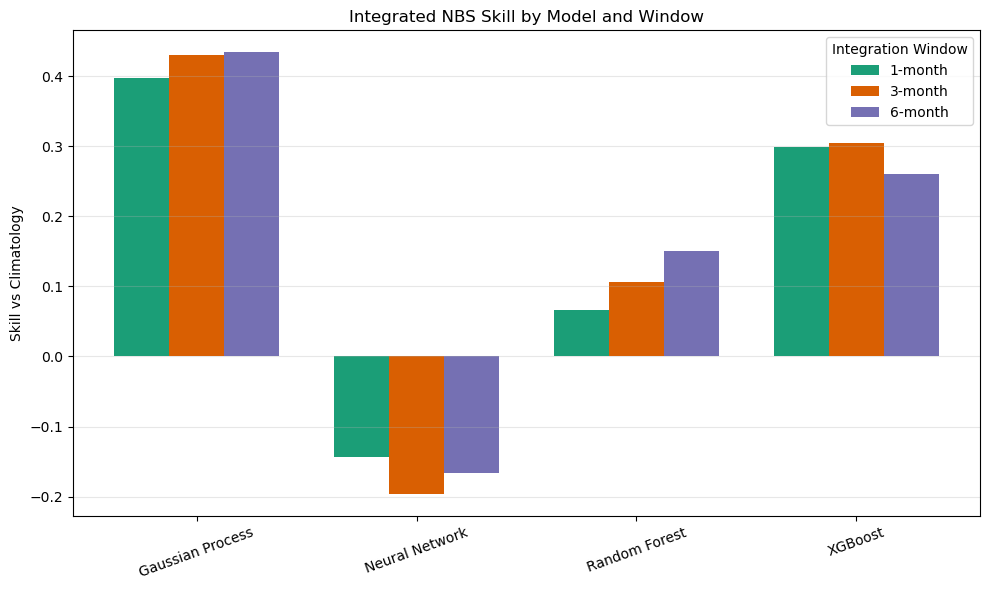

In [52]:
skill_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="Skill"
).sort_index()

models = skill_pivot.index
windows = skill_pivot.columns

colors = ["#1b9e77", "#d95f02", "#7570b3"]  # Dark2

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        skill_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("Skill vs Climatology")
ax.set_title("Integrated NBS Skill by Model and Window")
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

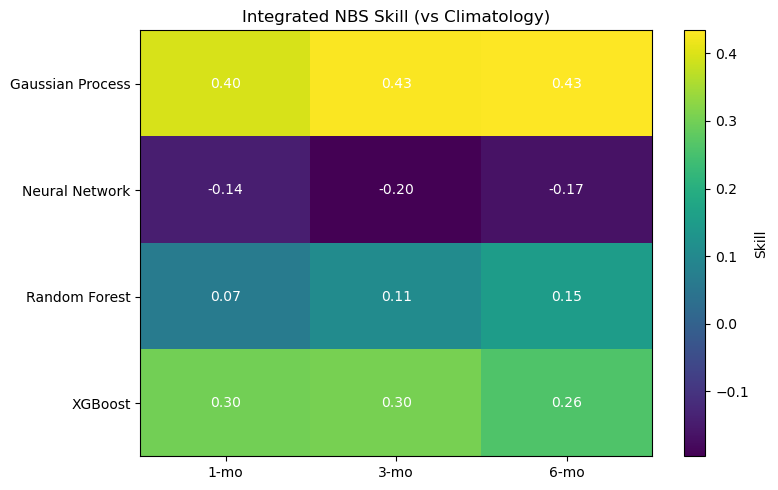

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

c = ax.imshow(skill_pivot.values, aspect='auto')

ax.set_xticks(range(len(windows)))
ax.set_xticklabels([f"{w}-mo" for w in windows])
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)

ax.set_title("Integrated NBS Skill (vs Climatology)")
plt.colorbar(c, label="Skill")

# Annotate cells
for i in range(len(models)):
    for j in range(len(windows)):
        ax.text(j, i, f"{skill_pivot.values[i, j]:.2f}",
                ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

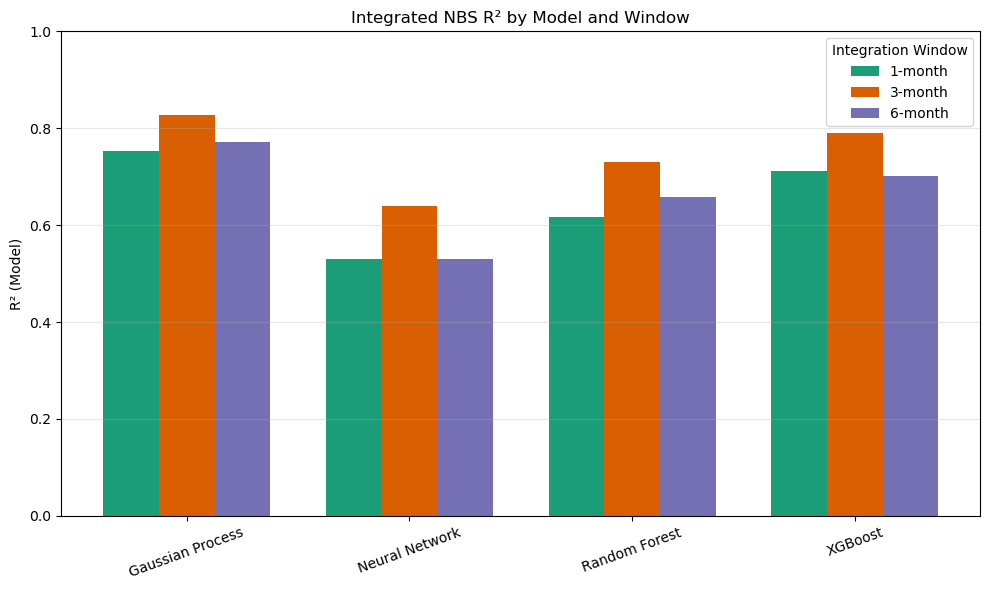

In [54]:
import matplotlib.pyplot as plt
import numpy as np

r2_model_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="R2_model"
).sort_index()

models = r2_model_pivot.index
windows = r2_model_pivot.columns

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        r2_model_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("R² (Model)")
ax.set_title("Integrated NBS R² by Model and Window")
ax.set_ylim(0, 1)
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

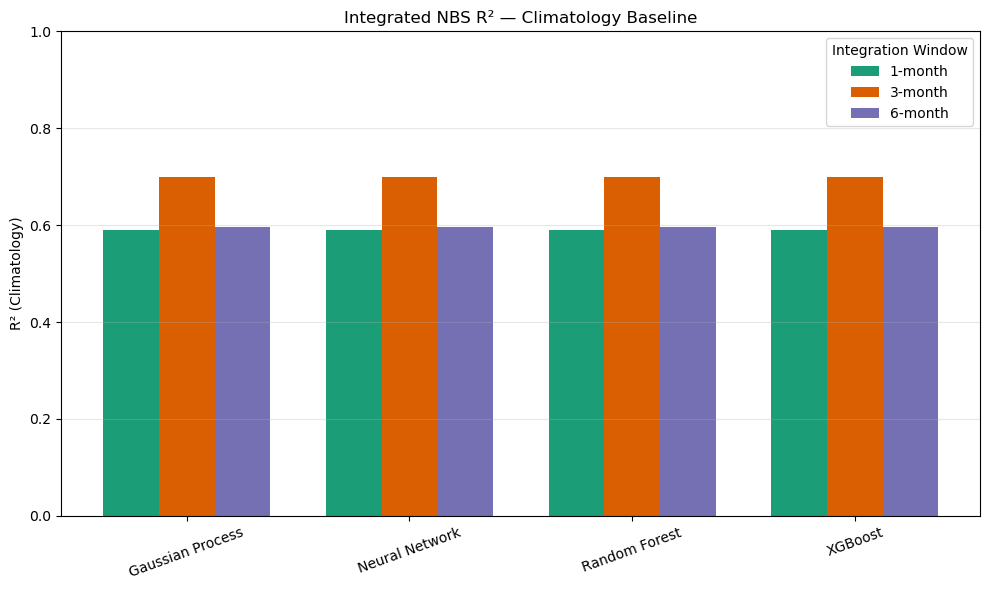

In [55]:
r2_clim_pivot = integrated_df.pivot(
    index="Model",
    columns="Window",
    values="R2_clim"
).sort_index()

models = r2_clim_pivot.index
windows = r2_clim_pivot.columns

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, w in enumerate(windows):
    ax.bar(
        x + i*width - width,
        r2_clim_pivot[w],
        width,
        label=f"{w}-month",
        color=colors[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.set_ylabel("R² (Climatology)")
ax.set_title("Integrated NBS R² — Climatology Baseline")
ax.set_ylim(0, 1)
ax.legend(title="Integration Window")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

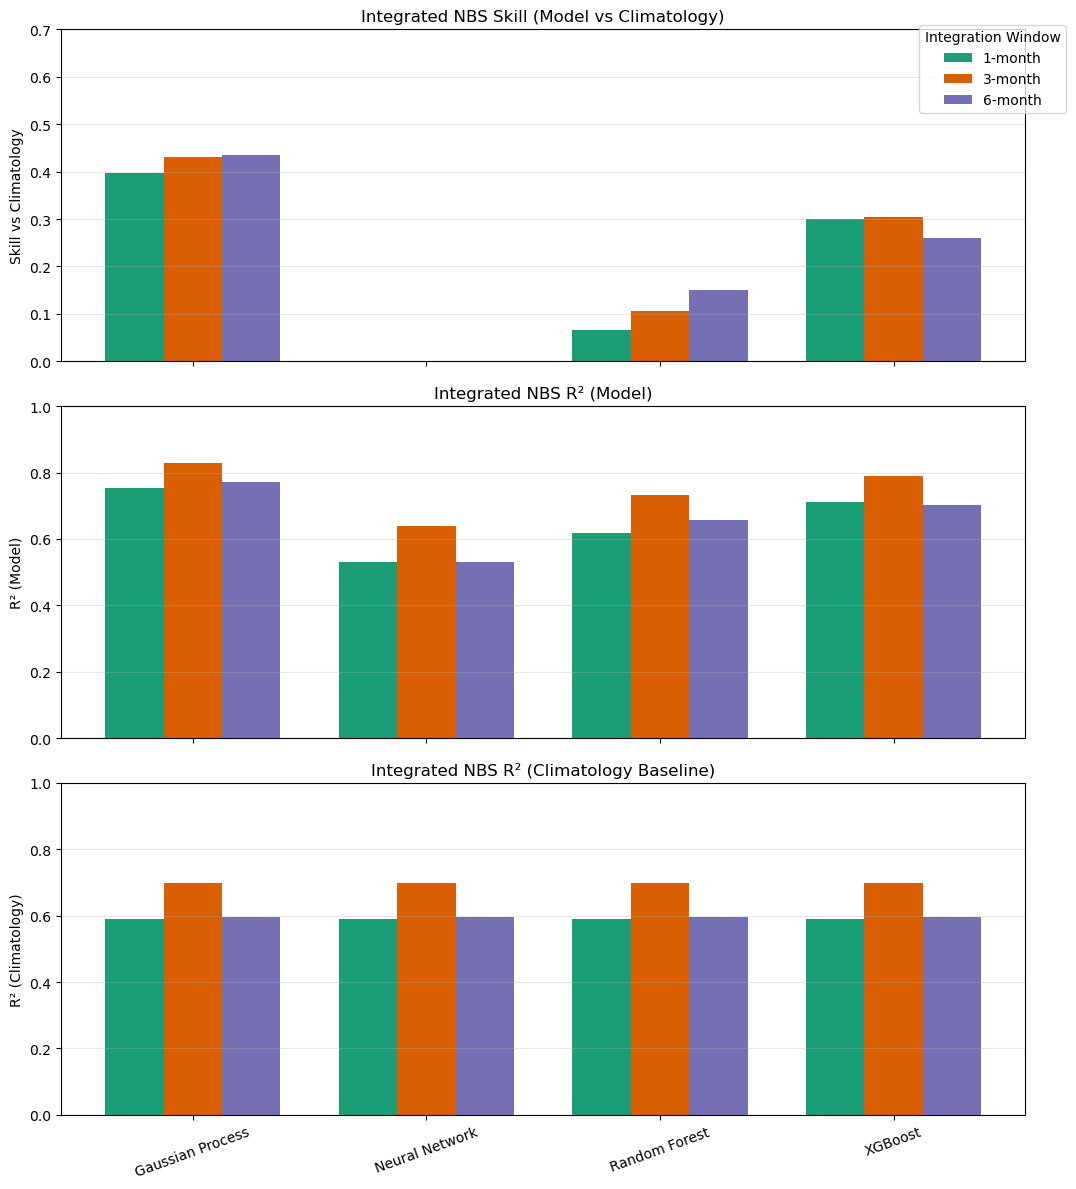

In [56]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["#1b9e77", "#d95f02", "#7570b3"]  # ColorBrewer Dark2 (colorblind-friendly)

def plot_grouped_bars(ax, pivot_df, ylabel, title, colors, ylim=(0, 1)):
    models = pivot_df.index
    windows = pivot_df.columns
    x = np.arange(len(models))
    width = 0.25

    for i, w in enumerate(windows):
        ax.bar(
            x + i*width - width,
            pivot_df[w].values,
            width,
            label=f"{w}-month",
            color=colors[i]
        )

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20)

# Pivot tables
skill_pivot = integrated_df.pivot(index="Model", columns="Window", values="Skill").sort_index()
r2_model_pivot = integrated_df.pivot(index="Model", columns="Window", values="R2_model").sort_index()
r2_clim_pivot  = integrated_df.pivot(index="Model", columns="Window", values="R2_clim").sort_index()

# Create stacked figure
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11, 12), sharex=True)

plot_grouped_bars(
    axes[0], skill_pivot,
    ylabel="Skill vs Climatology",
    title="Integrated NBS Skill (Model vs Climatology)",
    colors=colors,
    ylim=(0, 0.7)  # skill is usually within [-inf, 1], but your range is positive and < 0.7
)

plot_grouped_bars(
    axes[1], r2_model_pivot,
    ylabel="R² (Model)",
    title="Integrated NBS R² (Model)",
    colors=colors,
    ylim=(0, 1)
)

plot_grouped_bars(
    axes[2], r2_clim_pivot,
    ylabel="R² (Climatology)",
    title="Integrated NBS R² (Climatology Baseline)",
    colors=colors,
    ylim=(0, 1)
)

# Put one legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Integration Window", loc="upper right", bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 0.95, 1])  # leave space for legend
plt.show()